## Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import h5py  
import seaborn as sns
from scipy.special import betaincinv
import scipy.stats as stats


from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata.utils import Cutout2D
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import Planck15  
from astropy.table import Table

import pdb
 
import torch
from typing import Optional, Tuple
from torch import Tensor

import pickle
from operator import itemgetter

import os
import sys
sys.path.append(r"C:\Users\usuario\Documents\TFG\florah\src")

from florah.models.rnn_model.rnn_generator import DataModule 


#import sklearn
#import plotly.express as px


In [2]:
def build_features(cosmos_cat,zbin,node_features):
    x = node_features['x']   # halo mass and concentration
    t = node_features['t']
    ra =   node_features['ra']
    dec = node_features['dec']
    sersic = node_features['sersic']
    bovert = node_features['bovert']
    morphology = node_features['morphology']
    idnumber = node_features['id']

    x_updated=[]
    t_updated=[]
    ra_updated=[]
    dec_updated=[]
    sersic_updated=[]
    bovert_updated=[]
    morphology_updated=[]
    id_updated=[]

    sel2_len_vec=[]
    n_chunks = len(x)

    for id_data, x_data, t_data,ra_data,dec_data,sersic_data, bovert_data, morphology_data in zip(idnumber,x,t,ra,dec,sersic,bovert, morphology):
        mass_last = x_data[-1,0]
        # we select galaxies with the following characteristics:
        sel2 = cosmos_cat.query("sfr_CIGALE > -15 and radius_sersic > 0  and mass_CIGALE>"+str(mass_last-1.5)+" and mass_CIGALE<"+str(mass_last+1.5)+ " and zpdf_med>"+str(zbin[0])+" and zpdf_med<"+str(zbin[1]))
        # we reduce sample size
        size_sample = int(len(sel2)*0.003)
        sel2 = sel2.sample(n=size_sample)

        #chunks=0
        for i in range(len(sel2)):
            new_entry  = [sel2['mass_CIGALE'].values[i], np.log10(Planck15.angular_diameter_distance(sel2.zpdf_med.values[i]).value * np.deg2rad(sel2.radius_sersic.values[i]) * 1e3), sel2['sfr_CIGALE'].values[i]] #log10 of stellar mass, galaxy radius and sfr, respectively.
            new_x = np.vstack([x_data, new_entry])

            new_entry = [1/(1+sel2.zpdf_med.values[i])] 
            new_t = np.vstack([t_data,new_entry])

            new_entry = [sel2.ra.values[i]] 
            new_ra = np.vstack([ra_data,new_entry])

            new_entry = [sel2.dec.values[i]] 
            new_dec = np.vstack([dec_data,new_entry])

            new_entry = [sel2.sersic.values[i]] 
            new_sersic = np.vstack([sersic_data,new_entry])

            new_entry = [sel2['b/t_f444w'].values[i]] 
            new_bovert = np.vstack([bovert_data,new_entry])

            new_entry = [sel2['morph_flag_f444w'].values[i]] 
            new_morphology= np.vstack([morphology_data,new_entry])

            new_entry = [sel2['id'].values[i]] 
            new_id= np.vstack([id_data,new_entry])

            #pdb.set_trace()

            # Convert the 'x_data' to a list of floats while ignoring non-numeric and 'inf' values and skipping the first row
            cleaned_x_mass = [float(value) for value in (new_x[0:,0]) if value != b'-' and value != b'-inf']
            cleaned_x_size = [float(value) for value in (new_x[0:,1]) if value != b'-' and value != b'-inf']
            cleaned_x_sfr = [float(value) for value in (new_x[0:,2]) if value != b'-' and value != b'-inf']
            x_copy = np.column_stack([cleaned_x_mass, cleaned_x_size, cleaned_x_sfr])

            cleaned_t = [float(value) for value in (new_t[0:,0]) if value != b'-' and value != b'-inf']
            cleaned_t = np.expand_dims(cleaned_t,1)

            cleaned_ra = [float(value) for value in (new_ra[0:,0]) if value != b'-' and value != b'-inf']
            cleaned_ra = np.expand_dims(cleaned_ra,1)

            cleaned_dec = [float(value) for value in (new_dec[0:,0]) if value != b'-' and value != b'-inf']
            cleaned_dec = np.expand_dims(cleaned_dec,1)

            cleaned_sersic = [float(value) for value in (new_sersic[0:,0]) if value != b'-' and value != b'-inf']
            cleaned_sersic = np.expand_dims(cleaned_sersic,1)

            cleaned_bovert = [float(value) for value in (new_bovert[0:,0]) if value != b'-' and value != b'-inf']
            cleaned_bovert = np.expand_dims(cleaned_bovert,1)

            cleaned_morphology = [float(value) for value in (new_morphology[0:,0]) if value != b'-' and value != b'-inf']
            cleaned_morphology = np.expand_dims(cleaned_morphology,1)

            cleaned_id = [float(value) for value in (new_id[0:,0]) if value != b'-' and value != b'-inf']
            cleaned_id = np.expand_dims(cleaned_id,1)

            x_updated.append(x_copy)
            t_updated.append(cleaned_t)
            ra_updated.append(cleaned_ra)
            dec_updated.append(cleaned_dec)
            sersic_updated.append(cleaned_sersic)
            bovert_updated.append(cleaned_bovert)
            morphology_updated.append(cleaned_morphology)
            id_updated.append(cleaned_id)
            #chunks+=1
            #pdb.set_trace()

        sel2_len_vec.append(len(sel2)) # we store len(sel2) for every iteration
        #if (len(sel2)!=chunks):
            #pdb.set_trace()
            #print('weird')
        

    # Store 'x_copy' and 't' data as lists of NumPy arrays in the 'node_features' dictionary
    node_features = {'id': [np.array(arr, dtype=np.float32) for arr in id_updated],'x': [np.array(arr, dtype=np.float32) for arr in x_updated], 't': [np.array(arr, dtype=np.float32) for arr in t_updated],'ra': [np.array(arr, dtype=np.float32) for arr in ra_updated],'dec': [np.array(arr, dtype=np.float32) for arr in dec_updated],'sersic': [np.array(arr, dtype=np.float32) for arr in sersic_updated],'bovert': [np.array(arr, dtype=np.float32) for arr in bovert_updated],'morphology': [np.array(arr, dtype=np.float32) for arr in morphology_updated]}
    #print("after features:", len(x_updated))
    return node_features, n_chunks, sel2_len_vec
           


In [ ]:
def build_roots(cosmos_cat,mass_bin,nsamples=100,zbins=[0,0.5,1]):
    # we select galaxies with the following characteristics:
    sel = cosmos_cat.query("sfr_CIGALE > -15 and radius_sersic > 0  and mass_CIGALE > "+str(mass_bin[0])+" and mass_CIGALE < " + str(mass_bin[1])+" and zpdf_med > "+str(zbins[0])+" and zpdf_med < "+str(zbins[1]))
    # we shuffle the order of the galaxies selected:
        ##### i think this way we reduce the chance that the model might learn from order 
    if len(sel)<nsamples:
        sel = sel.sample(frac=1)
    else:
        sel = sel.sample(nsamples)
    
    
    n_chunks = len(sel) #seleccionamos chunks

    x = []
    t = []
    ravec=[]
    decvec=[]
    sersicvec=[]
    bovertvec=[]
    morphologyvec=[]
    len_sel2_vec=[]
    idvec = []
    node_features = {'x': None, 't': None, 'ra': None, 'dec': None}
    for idnumber, mass, z, re, ra, dec, SFR, sersic, bovert, morphology in zip(sel['id'].values, sel['mass_CIGALE'].values, sel.zpdf_med.values, sel.radius_sersic.values, sel.ra.values, sel.dec.values, sel['sfr_CIGALE'].values, sel.sersic.values, sel['b/tf444w'].values, sel['morph_flag_f444w'].values):
        x_data=np.zeros((2,3))
        t_data=np.zeros(2)
        ra_data = np.zeros(2)
        dec_data = np.zeros(2)
        sersic_data= np.zeros(2)
        bovert_data=np.zeros(2)
        morphology_data =np.zeros(2)
        id_data = np.zeros(2)
        
        x_data[0,0]= mass
        x_data[0,1]= Planck15.angular_diameter_distance(z).value * np.deg2rad(re) * 1e3
        x_data[0,2]= SFR

        t_data[0] = 1/(1+z) 
        ra_data[0] = ra
        dec_data[0] = dec
        sersic_data[0]=sersic
        bovert_data[0]=bovert
        morphology_data[0]=morphology 
        id_data[0]=idnumber

        # we select only the galaxies in the next bin, but we use a filter for mass 
        sel2 =  cosmos_cat.query("sfr_CIGALE > -15 and radius_sersic > 0  and mass_CIGALE>"+str(mass-1.5)+ " and mass_CIGALE<"+str(mass+0.5)+" and zpdf_med>"+str(zbins[1])+" and zpdf_med<"+str(zbins[2]))
        sel2 = sel2.sample(frac=0.03)
        chunks=0
        
        for i in range(len(sel2)):

            # Append 'x_data' and 't_data' for the current galaxy in the second bin
   
            x_data[1,0]= sel2['mass_CIGALE'].values[i]
            x_data[1,1]= Planck15.angular_diameter_distance(sel2.zpdf_med.values[i]).value * np.deg2rad(sel2.radius_sersic.values[i]) * 1e3
            x_data[1,2]= sel2['sfr_CIGALE'].values[i]

            t_data[1]=1/(1+sel2.zpdf_med.values[i])  
            ra_data[1] = sel2.ra.values[i]
            dec_data[1] =sel2.dec.values[i]
            sersic_data[1]=sel2.sersic.values[i]
            bovert_data[1]=sel2['b/t_f444w'].values[i]
            morphology_data[1]=sel2['morph_flag_f444w'].values[i]
            id_data[1]=sel2['id'].values[i]

            # Convert the 'x_data' to a list of floats while ignoring non-numeric and 'inf' values and skipping the first row
            cleaned_x_mass = [float(value) for value in (x_data[0:,0]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_x_size = [float(value) for value in (x_data[0:,1]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_x_SFR = [float(value) for value in (x_data[0:,2]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
           
            if len(cleaned_x_SFR) != len(x_data):
                print('caution!')
            x_copy = np.column_stack([cleaned_x_mass, np.log10(cleaned_x_size), cleaned_x_SFR])

            # Convert the 't_data' to a list of floats while ignoring non-numeric and 'inf' values and skipping the first row
            cleaned_t = [float(value) for value in (t_data[0:]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_t = np.expand_dims(cleaned_t,1)

            cleaned_ra = [float(value) for value in (ra_data[0:]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_ra = np.expand_dims(cleaned_ra,1)
            

            cleaned_dec = [float(value) for value in (dec_data[0:]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_dec = np.expand_dims(cleaned_dec,1)

            cleaned_sersic = [float(value) for value in (sersic_data[0:]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_sersic = np.expand_dims(cleaned_sersic,1)

            cleaned_bovert = [float(value) for value in (bovert_data[0:]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_bovert = np.expand_dims(cleaned_bovert,1)

            cleaned_morphology = [float(value) for value in (morphology_data[0:]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_morphology = np.expand_dims(cleaned_morphology,1)

            cleaned_id = [float(value) for value in (id_data[0:]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_id = np.expand_dims(cleaned_id,1)
           
            # Append the cleaned 'x' and 't' data to their respective lists
            x.append(x_copy)
            t.append(cleaned_t)
            ravec.append(cleaned_ra)
            decvec.append(cleaned_dec)
            sersicvec.append(cleaned_sersic)
            bovertvec.append(cleaned_bovert)
            morphologyvec.append(cleaned_morphology)
            idvec.append(cleaned_id)
            #print('x_copy:', x_copy.shape)
            chunks+=1
        len_sel2_vec.append(chunks)
        if (len(sel2)!=chunks):
            print('weird')
        #print("lengths:",chunks,len(sel2))



    

    # Store 'x_copy' and 't' data as lists of NumPy arrays in the 'node_features' dictionary
    node_features = {'id': [np.array(arr, dtype=np.float32) for arr in idvec],'x': [np.array(arr, dtype=np.float32) for arr in x], 't': [np.array(arr, dtype=np.float32) for arr in t],'ra': [np.array(arr, dtype=np.float32) for arr in ravec],'dec': [np.array(arr, dtype=np.float32) for arr in decvec],'sersic': [np.array(arr, dtype=np.float32) for arr in sersicvec],'bovert': [np.array(arr, dtype=np.float32) for arr in bovertvec],'morphology': [np.array(arr, dtype=np.float32) for arr in morphologyvec]}
   
    return node_features,n_chunks,len_sel2_vec


In [4]:
def build_roots_optimized(cosmos_cat, mass_bin, nsamples=100, zbins=[0, 0.5, 1]):
    """
    Versión optimizada de build_roots.
    Genera pares iniciales de galaxias (Raíz -> Candidato) para iniciar los árboles.
    """
    
    # ---------------------------------------------------------
    # 1. PREPARACIÓN DE PISCINAS (POOLS) DE DATOS
    # ---------------------------------------------------------
    
    # Pool A: RAÍCES (Z entre zbins[0] y zbins[1], y masa en mass_bin)
    mask_roots = (
        (cosmos_cat['zpdf_med'] > zbins[0]) & 
        (cosmos_cat['zpdf_med'] < zbins[1]) & 
        (cosmos_cat['mass_CIGALE'] > mass_bin[0]) & 
        (cosmos_cat['mass_CIGALE'] < mass_bin[1])
    )
    pool_roots = cosmos_cat[mask_roots].copy()
    
    # Pool B: CANDIDATOS A PAREJA (Z entre zbins[1] y zbins[2])
    # Nota: No filtramos masa aquí aún, porque depende de cada raíz individual
    mask_candidates = (
        (cosmos_cat['zpdf_med'] > zbins[1]) & 
        (cosmos_cat['zpdf_med'] < zbins[2])
    )
    pool_candidates = cosmos_cat[mask_candidates].copy()
    
    # Si no hay datos suficientes, devolvemos vacío
    if pool_roots.empty or pool_candidates.empty:
        print("Advertencia: No se encontraron galaxias suficientes en los rangos de Z o Masa.")
        empty_out = {'x': [], 't': [], 'ra': [], 'dec': [], 'sersic': [], 'bovert': [], 'morphology': [], 'id': []}
        return empty_out, 0, []

    # ---------------------------------------------------------
    # 2. SELECCIÓN DE RAÍCES (NSAMPLES)
    # ---------------------------------------------------------
    if len(pool_roots) < nsamples:
        # Si hay menos de nsamples, las cogemos todas pero barajadas
        pool_roots = pool_roots.sample(frac=1)
    else:
        # Si hay más, cogemos nsamples al azar
        pool_roots = pool_roots.sample(n=nsamples)
        
    n_roots = len(pool_roots)
    
    # ---------------------------------------------------------
    # 3. EXTRACCIÓN A NUMPY (VELOCIDAD MÁXIMA)
    # ---------------------------------------------------------
    # Convertimos los DataFrames a diccionarios de arrays para acceso rápido
    # Raíces (Padres)
    r_mass = pool_roots['mass_CIGALE'].values
    r_sfr  = pool_roots['sfr_CIGALE'].values
    r_rad  = pool_roots['log_radius_kpc'].values
    r_z    = pool_roots['zpdf_med'].values
    r_ra   = pool_roots['ra'].values
    r_dec  = pool_roots['dec'].values
    r_ser  = pool_roots['sersic'].values
    r_bov  = pool_roots['bovert'].values
    r_mor  = pool_roots['morphology'].values
    r_id   = pool_roots['id'].values

    # Candidatos (Hijos potenciales)
    c_mass = pool_candidates['mass_CIGALE'].values
    c_sfr  = pool_candidates['sfr_CIGALE'].values
    c_rad  = pool_candidates['log_radius_kpc'].values
    c_z    = pool_candidates['zpdf_med'].values
    c_ra   = pool_candidates['ra'].values
    c_dec  = pool_candidates['dec'].values
    c_sersic = pool_candidates['sersic'].values
    c_bovert = pool_candidates['bovert'].values
    c_morph = pool_candidates['morphology'].values
    c_id   = pool_candidates['id'].values

    # Listas para guardar resultados
    out = {k: [] for k in ['x', 't', 'ra', 'dec', 'sersic', 'bovert', 'morphology', 'id']}
    len_sel2_vec = []
    
    total_pairs = 0

    # ---------------------------------------------------------
    # 4. BUCLE PRINCIPAL (Iterar sobre cada Raíz)
    # ---------------------------------------------------------
    for i in range(n_roots):
        
        # Masa de la raíz actual
        current_mass = r_mass[i]
        
        # FILTRO VECTORIZADO: Buscamos candidatos que cumplan la asimetría de masa
        # Condición: mass_root - 1.5 < mass_candidato < mass_root + 0.5
        mask_matches = (c_mass > (current_mass - 1.5)) & (c_mass < (current_mass + 0.5))
        
        # Índices de los candidatos que cumplen
        match_indices = np.where(mask_matches)[0]
        n_matches = len(match_indices)
        
        # Muestreo del 3% (frac=0.03)
        if n_matches > 0:
            n_sample = int(n_matches * 0.03)
            # Aseguramos al menos 1 si sale 0 por redondeo? 
            # Tu código original usa int(), así que si es < 33 matches, sale 0. Respetamos eso.
            
            if n_sample > 0:
                chosen_indices = np.random.choice(match_indices, size=n_sample, replace=False)
                
                # CREACIÓN DE PARES (Raíz -> Candidato)
                # Iteramos sobre los elegidos para construir los pares
                for idx in chosen_indices:
                    # Datos Raíz (Fila 0)
                    row0_x = [r_mass[i], r_rad[i], r_sfr[i]]
                    row0_t = [1.0 / (1.0 + r_z[i])]
                    row0_ra = [r_ra[i]]
                    row0_dec = [r_dec[i]]
                    row0_ser = [r_ser[i]]
                    row0_bov = [r_bov[i]]
                    row0_mor = [r_mor[i]]
                    row0_id = [r_id[i]]
                    
                    # Datos Candidato (Fila 1)
                    row1_x = [c_mass[idx], c_rad[idx], c_sfr[idx]]
                    row1_t = [1.0 / (1.0 + c_z[idx])]
                    row1_ra = [c_ra[idx]]
                    row1_dec = [c_dec[idx]]
                    row1_ser = [c_sersic[idx]]
                    row1_bov = [c_bovert[idx]]
                    row1_mor = [c_morph[idx]]
                    row1_id = [c_id[idx]]
                    
                    # Apilamos verticalmente (vstack) para crear arrays de shape (2, N)
                    out['x'].append(np.array([row0_x, row1_x], dtype=np.float32))
                    out['t'].append(np.array([row0_t, row1_t], dtype=np.float32)) # Shape (2,1)
                    out['ra'].append(np.array([row0_ra, row1_ra], dtype=np.float32))
                    out['dec'].append(np.array([row0_dec, row1_dec], dtype=np.float32))
                    out['sersic'].append(np.array([row0_ser, row1_ser], dtype=np.float32))
                    out['bovert'].append(np.array([row0_bov, row1_bov], dtype=np.float32))
                    out['morphology'].append(np.array([row0_mor, row1_mor], dtype=np.float32))
                    out['id'].append(np.array([row0_id, row1_id], dtype=np.float32))
                    
                    total_pairs += 1
            
            len_sel2_vec.append(n_sample) # Guardamos cuántos se usaron realmente
        else:
            len_sel2_vec.append(0)

    # Convertir listas a arrays de numpy para la estructura final si fuera necesario,
    # pero tu código retorna listas de arrays, así que esto está listo.
    
    return out, n_roots, len_sel2_vec

In [5]:
def build_features_optimized(cosmos_cat, zbin, node_features, sample_fraction=0.003):
    """
    Versión optimizada y CORREGIDA de build_features.
    Ahora sel2_len_vec devuelve el tamaño real muestreado, no el total encontrado.
    """
    
    # 1. PRE-FILTRADO GLOBAL
    mask_z = (cosmos_cat['zpdf_med'] > zbin[0]) & (cosmos_cat['zpdf_med'] < zbin[1])
    cosmos_slice = cosmos_cat[mask_z].copy()
    
    if cosmos_slice.empty:
        print("No se encontraron galaxias en el rango de Z especificado.")
        # Retornamos vector de ceros para mantener consistencia
        return {k: [] for k in node_features}, 0, [0]*len(node_features['x'])

    # Extraemos columnas a arrays
    c_mass = cosmos_slice['mass_CIGALE'].values
    c_sfr = cosmos_slice['sfr_CIGALE'].values
    c_rad = cosmos_slice['log_radius_kpc'].values
    c_z = cosmos_slice['zpdf_med'].values
    c_ra = cosmos_slice['ra'].values
    c_dec = cosmos_slice['dec'].values
    c_sersic = cosmos_slice['sersic'].values
    c_bovert = cosmos_slice['bovert'].values
    c_morph = cosmos_slice['morphology'].values
    c_id = cosmos_slice['id'].values

    # Estructuras para guardar resultados
    out = {k: [] for k in ['x', 't', 'ra', 'dec', 'sersic', 'bovert', 'morphology', 'id']}
    sel2_len_vec = [] # Aquí guardaremos el tamaño REAL de los hijos generados
    
    ids_in = node_features['id']
    xs_in = node_features['x']
    ts_in = node_features['t']
    ras_in = node_features['ra']
    decs_in = node_features['dec']
    sersics_in = node_features['sersic']
    boverts_in = node_features['bovert']
    morphs_in = node_features['morphology']
    
    n_chunks = len(xs_in)

    # 2. BUCLE PRINCIPAL
    for i in range(n_chunks):
        
        mass_last = xs_in[i][-1, 0]
        
        # Filtrado por masa
        mass_mask = np.abs(c_mass - mass_last) < 1.5
        candidate_indices = np.where(mass_mask)[0]
        n_candidates = len(candidate_indices)
        
        # --- CORRECCIÓN AQUÍ ---
        # No guardamos n_candidates todavía en la lista final.
        # Primero calculamos cuántos vamos a usar realmente.
        
        actual_children_count = 0 
        
        if n_candidates > 0:
            # Calculamos el sample size
            size_sample = int(n_candidates * sample_fraction)
            
            if size_sample > 0:
                # Elegimos índices
                chosen_indices = np.random.choice(candidate_indices, size=size_sample, replace=False)
                actual_children_count = len(chosen_indices)
                
                # Preparamos datos padre
                p_x = xs_in[i]
                p_t = ts_in[i]
                p_ra = ras_in[i]
                p_dec = decs_in[i]
                p_ser = sersics_in[i]
                p_bov = boverts_in[i]
                p_mor = morphs_in[i]
                p_id = ids_in[i]

                # Construimos las ramas
                for idx in chosen_indices:
                    new_row_x = np.array([c_mass[idx], c_rad[idx], c_sfr[idx]], dtype=np.float32)
                    new_row_t = np.array([1.0 / (1.0 + c_z[idx])], dtype=np.float32)
                    
                    new_row_ra = np.array([c_ra[idx]], dtype=np.float32)
                    new_row_dec = np.array([c_dec[idx]], dtype=np.float32)
                    new_row_ser = np.array([c_sersic[idx]], dtype=np.float32)
                    new_row_bov = np.array([c_bovert[idx]], dtype=np.float32)
                    new_row_mor = np.array([c_morph[idx]], dtype=np.float32)
                    new_row_id = np.array([c_id[idx]], dtype=np.float32)

                    out['x'].append(np.vstack([p_x, new_row_x]))
                    out['t'].append(np.vstack([p_t, new_row_t]))
                    out['ra'].append(np.vstack([p_ra, new_row_ra]))
                    out['dec'].append(np.vstack([p_dec, new_row_dec]))
                    out['sersic'].append(np.vstack([p_ser, new_row_ser]))
                    out['bovert'].append(np.vstack([p_bov, new_row_bov]))
                    out['morphology'].append(np.vstack([p_mor, new_row_mor]))
                    out['id'].append(np.vstack([p_id, new_row_id]))
        
        # --- FIN DE LA CORRECCIÓN ---
        # Ahora sí guardamos el número real de hijos generados (0 o N)
        # Esto asegura que sum(sel2_len_vec) == len(node_features_generated)
        sel2_len_vec.append(actual_children_count)

    return out, n_chunks, sel2_len_vec

In [6]:
def get_maxlike_descendant(l_numpy,node_features, num_chunks,chunk_size,step=1):

    x=node_features['x']
    t=node_features['t']
    ra=node_features['ra']
    dec=node_features['dec']
    sersic = node_features['sersic']
    bovert = node_features['bovert']
    morphology = node_features['morphology']
    idvec=node_features['id']
    # Calculate the number of chunks
    
    
    id_sel=[]
    x_sel=[]
    t_sel=[]
    ra_sel=[]
    dec_sel=[]
    sersic_sel=[]
    bovert_sel=[]
    morphology_sel=[]

    if step>1:
        l_numpy = l_numpy[step-1::step]
    #num_chunks = len(l_numpy) // chunk_size    
    start_idx =0
    end_idx=0
    for i in range(num_chunks):
        if i==0:
            start_idx=0
        else:
            start_idx = end_idx
        
        end_idx += chunk_size[i]
        #print(start_idx,end_idx)
        chunk = l_numpy[start_idx:end_idx]

        # Find the maximum value and its position in the chunk
        max_value = np.max(chunk)
        max_position = np.argmax(chunk)
        if len([start_idx + max_position])>1:
            print('weird!')
            

        x_sel.append(x[start_idx + max_position])
        t_sel.append(t[start_idx + max_position])
        ra_sel.append(ra[start_idx + max_position])
        dec_sel.append(dec[start_idx + max_position])
        sersic_sel.append(sersic[start_idx + max_position])
        bovert_sel.append(bovert[start_idx + max_position])
        morphology_sel.append(morphology[start_idx + max_position])
        id_sel.append(idvec[start_idx + max_position])

        
    node_features_updated = {'id': [np.array(arr, dtype=np.float32) for arr in id_sel], 'x': [np.array(arr, dtype=np.float32) for arr in x_sel], 't': [np.array(arr, dtype=np.float32) for arr in t_sel],'ra': [np.array(arr, dtype=np.float32) for arr in ra_sel],'dec': [np.array(arr, dtype=np.float32) for arr in dec_sel],'sersic': [np.array(arr, dtype=np.float32) for arr in sersic_sel],'bovert': [np.array(arr, dtype=np.float32) for arr in bovert_sel],'morphology': [np.array(arr, dtype=np.float32) for arr in morphology_sel]}
    #print("after max selection:", len(x_sel))
    return node_features_updated

In [7]:
def get_maxlike_descendant_optimized(l_numpy, node_features, num_chunks, chunk_size, step=1):
    """
    Selecciona el descendiente con mayor likelihood para cada halo padre de forma vectorizada.
    """
    
    # 1. PRE-PROCESAMIENTO DE L_NUMPY
    # Aplicamos el paso (step) inicial si es necesario
    if step > 1:
        # Nota: Asumimos que chunk_size corresponde a la longitud DEPUÉS de este slice
        l_numpy = l_numpy[step-1::step]

    # Verificación de seguridad
    if len(l_numpy) != np.sum(chunk_size):
        # Esto suele pasar si chunk_size no está alineado con los datos filtrados
        raise ValueError(f"Desajuste: l_numpy tiene {len(l_numpy)} elementos pero la suma de chunk_size es {np.sum(chunk_size)}")

    # 2. VECTORIZACIÓN DE LA BÚSQUEDA (El corazón de la optimización)
    # En lugar de un bucle, creamos un array que identifica a qué padre pertenece cada likelihood.
    # Ej: si chunk_size es [2, 3], parent_ids será [0, 0, 1, 1, 1]
    parent_ids = np.repeat(np.arange(num_chunks), chunk_size)
    
    # Creamos un DataFrame temporal para usar la potencia de Pandas
    # Esto es mucho más rápido que iterar manualmente arrays irregulares
    df = pd.DataFrame({
        'likelihood': l_numpy,
        'parent_id': parent_ids,
        'global_index': np.arange(len(l_numpy)) # Guardamos el índice original para extraer luego
    })
    
    # Encontramos el índice global del valor máximo para cada padre
    # idxmax() nos da el índice del DF, luego sacamos la columna 'global_index'
    best_indices = df.loc[df.groupby('parent_id')['likelihood'].idxmax(), 'global_index'].values
    
    # Ordenamos los índices para mantener el orden de los padres (0, 1, 2...)
    # (groupby suele ordenar por defecto, pero es mejor asegurar)
    best_indices.sort()

    # 3. EXTRACCIÓN RÁPIDA DE DATOS
    # Usamos itemgetter o list comprehension para sacar los elementos ganadores de las listas originales
    # Esto es mucho más rápido que hacer x_sel.append() un millón de veces
    
    keys_to_extract = ['x', 't', 'ra', 'dec', 'sersic', 'bovert', 'morphology', 'id']
    node_features_updated = {}

    for key in keys_to_extract:
        original_list = node_features[key]
        # Selección directa usando los índices ganadores
        selected_items = [original_list[i] for i in best_indices]
        
        # Opcional: Si necesitas asegurar que sean arrays de float32 como en tu original
        # Aunque generalmente ya lo son si vienen de build_features
        # selected_items = [np.array(arr, dtype=np.float32) for arr in selected_items]
        
        node_features_updated[key] = selected_items

    # print("After max selection:", len(best_indices))
    return node_features_updated

In [8]:
def get_maxlike_descendant_final(l_numpy, node_features, num_chunks, chunk_size):
    """
    Versión blindada y optimizada.
    Elimina automáticamente el parámetro 'step' (usa todos los datos) 
    y corrige desajustes de longitud en l_numpy.
    """
    
    # 1. CORRECCIÓN DE LONGITUD (Safety Check)
    total_expected = np.sum(chunk_size)
    total_actual = len(l_numpy)
    
    if total_actual > total_expected:
        # Si sobran datos, recortamos el exceso del final
        diff = total_actual - total_expected
        # print(f"Aviso: Recortando {diff} elementos sobrantes de l_numpy para coincidir con chunk_size.")
        l_numpy = l_numpy[:total_expected]
        
    elif total_actual < total_expected:
        # Si faltan datos, esto es un error crítico que no podemos inventar
        raise ValueError(f"Error Crítico: Faltan datos. Hay {total_actual} likelihoods pero se esperaban {total_expected}.")

    # 2. VECTORIZACIÓN (Igual que antes, pero ahora seguro)
    # Creamos el array de IDs de padres repetidos según el tamaño de sus chunks
    parent_ids = np.repeat(np.arange(num_chunks), chunk_size)
    
    # Creamos DataFrame temporal
    df = pd.DataFrame({
        'likelihood': l_numpy,
        'parent_id': parent_ids,
        'global_index': np.arange(len(l_numpy))
    })
    
    # Encontramos el índice global del máximo likelihood para cada padre
    # idxmax nos da el índice del DF donde está el máximo
    best_indices = df.loc[df.groupby('parent_id')['likelihood'].idxmax(), 'global_index'].values
    
    # Ordenamos para mantener el orden de los padres (0, 1, 2...)
    best_indices.sort()

    # 3. EXTRACCIÓN DE DATOS
    keys_to_extract = ['x', 't', 'ra', 'dec', 'sersic', 'bovert', 'morphology', 'id']
    node_features_updated = {}

    for key in keys_to_extract:
        original_list = node_features[key]
        
        # Verificación extra por si node_features tiene una longitud distinta
        # (A veces node_features acumula basura también)
        if len(original_list) > len(l_numpy):
             original_list = original_list[:len(l_numpy)]
             
        # Extracción directa usando los índices ganadores
        selected_items = [original_list[i] for i in best_indices]
        node_features_updated[key] = selected_items

    return node_features_updated

In [9]:
def log_likelihood_obs(
        model: torch.nn.Module, batch: Tuple[Tensor],
        to_numpy: bool = True,  batch_size: int = 4096
    ):
    """ Sample trees using Recurrent-MAF model
    Parameters
    ----------
    model: torch.nn.Module
        Recurrent model
    roots: np.ndarray
        Root features
    times: np.ndarray
        Time features
    to_numpy: bool
        Whether to convert to numpy
    device: Optional
        Device to use
    batch_size: int

    Returns
    -------
    x: Union[Tensor, np.ndarray]
        Sampled trees
    """

    device ='cpu'
    model = model.to(device)

    #seq_len = len(roots)+1
    #mask = np.expand_dims(np.zeros(seq_len),axis=0)
    #mask = np.zeros((1, seq_len), dtype=np.bool)
    #mask[:, :seq_len] = True
    #t = np.concatenate((times, t_obs),axis=1)

    #x_tensor = torch.from_numpy(roots.astype('float32'))
    #y_tensor = torch.from_numpy(obs.astype('float32'))
    #t_tensor = torch.from_numpy(t.astype('float32'))
    #seq_len_tensor = torch.tensor(seq_len, dtype=torch.int32)
    #mask_tensor = torch.from_numpy(mask)

    #tensor_tuple = (x_tensor, y_tensor, t_tensor, seq_len_tensor, mask_tensor)

    lp=model.log_prob(batch,return_context=False)

   
    return lp

## Load data and model

In [10]:
# Load the trained model from a checkpoint file
checkpoint_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\last-v1.ckpt"  # Specify the path to your checkpoint file
loaded_model = DataModule.load_from_checkpoint(checkpoint_path,map_location='cpu', weights_only=False)


# Set the model to evaluation mode (important if you have dropout or batch normalization layers)
loaded_model.eval()

DataModule(
  (model): RecurrentMAF(
    (embedding_net): Identity()
    (rnn): ModuleList(
      (0): GRU(5, 128, batch_first=True)
      (1-3): 3 x GRU(128, 128, batch_first=True)
    )
    (maf_blocks): Flow(
      (_transform): CompositeTransform(
        (_transforms): ModuleList(
          (0): CompositeTransform(
            (_transforms): ModuleList(
              (0-3): 4 x CompositeTransform(
                (_transforms): ModuleList(
                  (0): MaskedAffineAutoregressiveTransform(
                    (autoregressive_net): MADE(
                      (initial_layer): MaskedLinear(in_features=3, out_features=128, bias=True)
                      (context_layer): Linear(in_features=128, out_features=128, bias=True)
                      (blocks): ModuleList(
                        (0-1): 2 x MaskedFeedforwardBlock(
                          (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
                          (line

In [11]:
cosmos_data_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\"
cosmos_cat = pd.read_csv(cosmos_data_path+"COSMOSWeb_Laura_processed.csv") # Data from COSMOS-WEB, converted from .fits to .csv in florah_eval_SFR.ipynb


In [12]:
print(f"Total de galaxias en el catálogo: {len(cosmos_cat)}")

Total de galaxias en el catálogo: 588536


#### Get files with predictions on progenitor-descendant


In [13]:
#redshifts = np.array([1.5,2,2.5,3,4,6])
nfm_data_path = "C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\node_features_morphology\\"
redshifts = np.array([1.,1.5,2,2.5,3.5,4.5,6])


mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

for m in mass_bin:
    node_features, n_chunks, chunk_size = build_roots_optimized(cosmos_cat, m, nsamples=100)
    print(f"Número de halos/nodos a procesar: {len(node_features['id'])}")
    preprocessed_node_features = loaded_model.transform(node_features, fit=False) ####### what does this do?
    l  = log_likelihood_obs(loaded_model,preprocessed_node_features)
    l_numpy = l.detach().numpy()
    node_features = get_maxlike_descendant_final(l.detach().numpy(),node_features,n_chunks,chunk_size)
    for zmin,zmax in zip(redshifts[:-1],redshifts[1:]):
        node_features,n_chunks,chunk_size = build_features_optimized(cosmos_cat,[zmin,zmax],node_features) ###### aquí falla
        preprocessed_node_features = loaded_model.transform(node_features, fit=False)
        l  = log_likelihood_obs(loaded_model,preprocessed_node_features)
        print('likelihood:', len(l.detach().numpy()))
        node_features = get_maxlike_descendant_final(l.detach().numpy(),node_features, n_chunks, chunk_size)
        
# Store node_features
    with open(nfm_data_path+'node_features_morphology'+str(m[0])+'_'+str(m[1])+'.pkl', 'wb') as outfile:
        pickle.dump(node_features, outfile)

Número de halos/nodos a procesar: 100653
likelihood: 25664
likelihood: 57597
likelihood: 51284
likelihood: 62895
likelihood: 46074
likelihood: 35903
Número de halos/nodos a procesar: 81419
likelihood: 20330
likelihood: 55770
likelihood: 48852
likelihood: 63665
likelihood: 45114
likelihood: 35210
Número de halos/nodos a procesar: 67289
likelihood: 16184
likelihood: 55899
likelihood: 49064
likelihood: 62945
likelihood: 46590
likelihood: 35651
Número de halos/nodos a procesar: 55228
likelihood: 11772
likelihood: 50145
likelihood: 50308
likelihood: 62120
likelihood: 45432
likelihood: 36414
Número de halos/nodos a procesar: 45802
likelihood: 9054
likelihood: 45225
likelihood: 46920
likelihood: 62270
likelihood: 45948
likelihood: 35581
Número de halos/nodos a procesar: 32869
likelihood: 6364
likelihood: 37848
likelihood: 43664
likelihood: 55545
likelihood: 41706
likelihood: 32389
Número de halos/nodos a procesar: 16129
likelihood: 2990
likelihood: 20625
likelihood: 27688
likelihood: 35080
li

In [14]:
datos1_data_path = 'C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\datos1\\'
print(len(node_features['x']))
# Iterate through the entries in the structure
for i in range(len(node_features['x'])):
    df = pd.DataFrame({
        'id': node_features['id'][i][:, 0],
        'x_mass': node_features['x'][i][:, 0],  # Assuming x_mass is the first column of x
        'x_size': node_features['x'][i][:, 1],  # Assuming x_size is the second column of x
        'x_SFR': node_features['x'][i][:, 2],  # Assuming x_sfr is the second column of x
        't': node_features['t'][i][:, 0],
        'ra': node_features['ra'][i][:, 0],
        'dec': node_features['dec'][i][:, 0],
        'sersic': node_features['sersic'][i][:, 0],
        'bovert': node_features['bovert'][i][:, 0],
        'morphology': node_features['morphology'][i][:, 0]
    })

    # Get the values for constructing the file name
    ra_val = node_features['ra'][i][0][0]
    dec_val = node_features['dec'][i][0][0]

    # Construct the file name
    file_name = f"COSMOS_{ra_val}_{dec_val}.csv"

    # Save the DataFrame as a CSV file
    df.to_csv(datos1_data_path+file_name, index=False)

57


In [15]:
datos2_data_path = 'C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\datos2\\'
file_list = []
mass_bin = [[9.8, 10], [10, 10.2], [10.2, 10.4], [10.4, 10.6], [10.6, 10.8], [10.8, 11], [11, 12]]

# Generate the list of file names based on node_features['id']
for m_bin in mass_bin:
    # Load node_features for the current mass bin
    with open(os.path.join(nfm_data_path, f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl'), 'rb') as infile:
        node_features = pickle.load(infile)
        
    for i in range(len(node_features['x'])):
        id_val = node_features['id'][i][0, 0]  # Ensure this is how your ID is structured
        file_name = f"{id_val}_SFH.fits"
        file_list.append(file_name)

# Generate a single string of file names separated by spaces for the tar command
file_list_str = ' '.join([datos2_data_path + file for file in file_list])

# Create the command to generate a tarball
tar_command = f"tar -czvf collected_files.tar.gz {file_list_str}"

# Write the command to a shell script file
script_file_name = "create_tarball.sh"
with open(nfm_data_path+script_file_name, 'w') as script_file:
    script_file.write("#!/bin/bash\n")
    script_file.write(tar_command + "\n")

# Make the script executable
os.chmod(nfm_data_path+script_file_name, 0o755)

print(f"The tar command has been saved in {script_file_name}")


The tar command has been saved in create_tarball.sh


## Data analysis

### graficas chiquitas

(57, 8, 3)


<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\248558741.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log M_*$',fontsize=20)


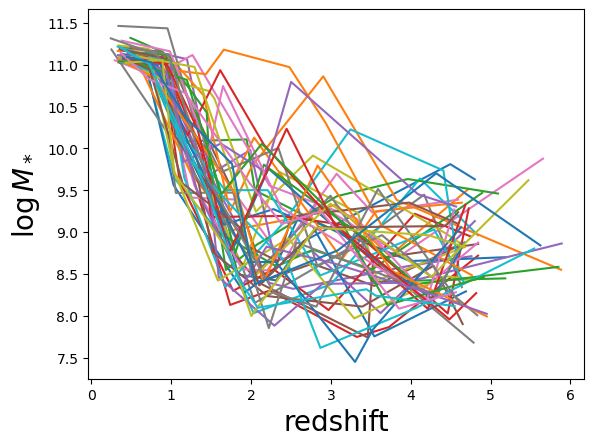

In [16]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(51):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,0]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log M_*$',fontsize=20)

plt.savefig('mass_growth_CEERS.png')

(57, 8, 3)


<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\483030535.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log M_*$',fontsize=20)


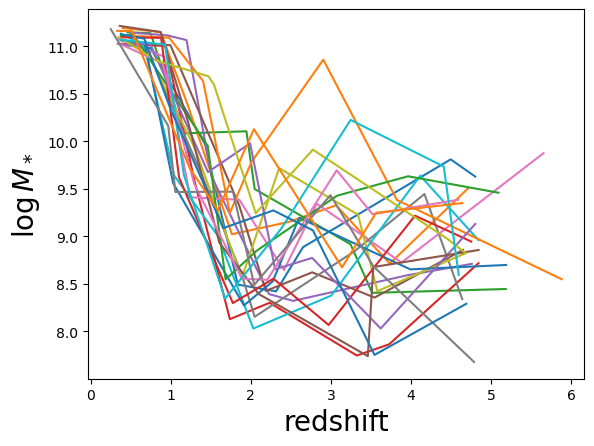

In [17]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(22):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,0]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log M_*$',fontsize=20)

plt.savefig('mass_growth_CEERS.png')

In [18]:
x_test = np.array(node_features['x'])
print((x_test[:,0,0]))

[11.019653  11.192241  11.147104  11.026943  11.143692  11.034384
 11.077337  11.014995  11.044025  11.132851  11.063323  11.110711
 11.10715   11.094447  11.019097  11.213863  11.030311  11.179144
 11.096325  11.069033  11.126216  11.162033  11.317778  11.172654
 11.118532  11.027899  11.049135  11.460677  11.226943  11.213507
 11.089231  11.130058  11.134508  11.06968   11.112554  11.185348
 11.284499  11.312008  11.077488  11.038116  11.084326  11.065427
 11.038785  11.089088  11.137631  11.069117  11.139275  11.209592
 11.021563  11.195974  11.089302  11.143061  11.075782  11.0153675
 11.008709  11.037093  11.3618765]


<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\2706922235.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log Re$',fontsize=20)


(57, 8, 3)


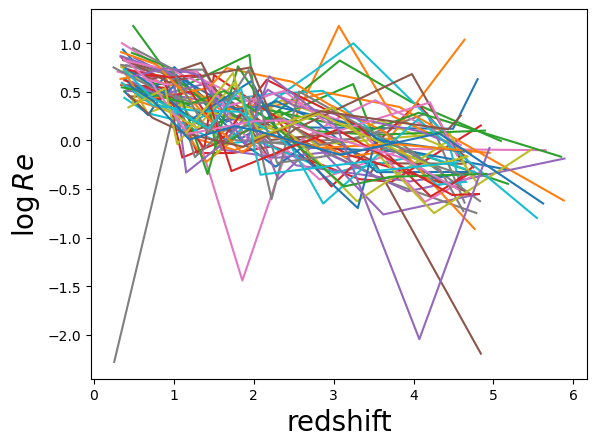

In [19]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(51):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,1]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log Re$',fontsize=20)

plt.savefig('re_growth_CEERS.png')

(57, 8, 3)


<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\3075396213.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log Re$',fontsize=20)


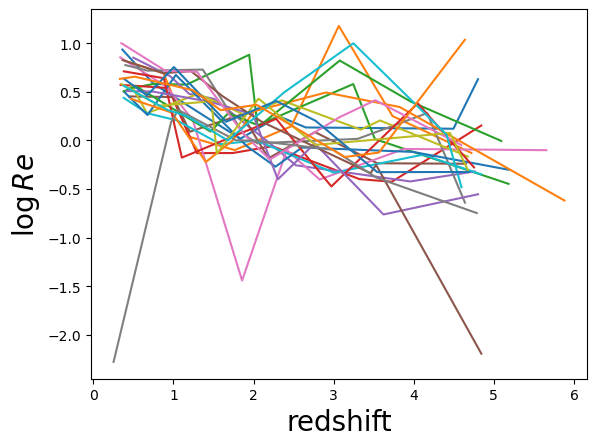

In [20]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(22):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,1]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log Re$',fontsize=20)

plt.savefig('re_growth_CEERS.png')

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\3426603825.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log SFR$',fontsize=20)


(57, 8, 3)


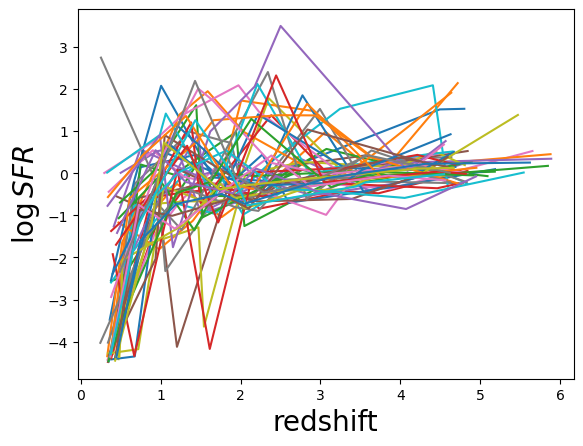

In [21]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(51):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,2]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)

plt.savefig('sfr_growth_CEERS.png')

### graficas grandes

<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:36: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\3646879630.py:36: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log$ SFR', fontsize=20)


Shapes: (176,) (176,)
[-2.89783051 -0.89442132 -0.29020625 -0.24816666 -0.15516802  0.24123407
  0.14845569  0.36164371]


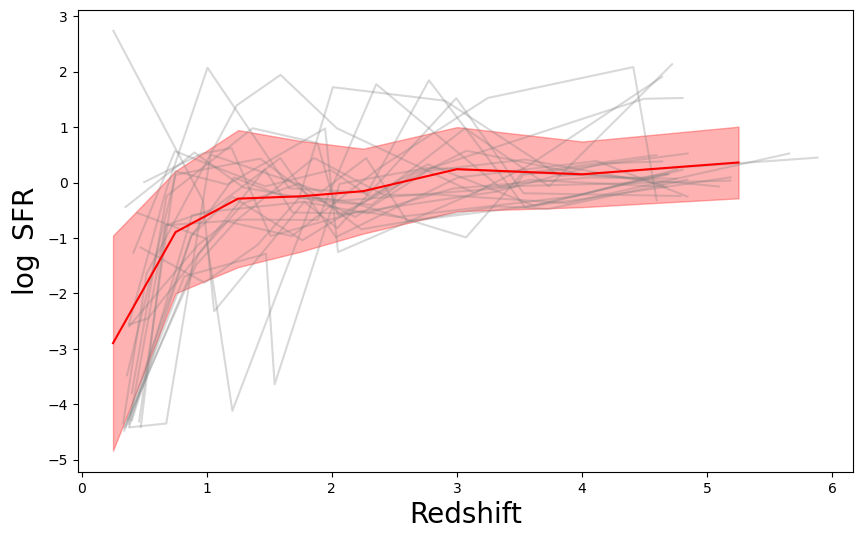

In [22]:
plt.figure(figsize=[10, 6])

all_sfrs = []
all_redshifts = []

for i in range(22):  # Assuming you have 51 entries based on your example
    redshifts = 1 / np.array(node_features['t'][i]) - 1
    sfr = np.array(node_features['x'][i][:, 2])
    plt.plot(redshifts, sfr, color='gray', alpha=0.3)

    all_redshifts.extend(redshifts)
    all_sfrs.extend(sfr)

# Make sure the data is in the correct numpy array format
all_redshifts_np = np.squeeze(np.array(all_redshifts))
all_sfrs_np = np.array(all_sfrs)

valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
filtered_redshifts = all_redshifts_np[valid_data_mask]
filtered_sfrs = all_sfrs_np[valid_data_mask]

# Verify shapes
print("Shapes:", all_redshifts_np.shape, all_sfrs_np.shape)

# Binning the data
bin_edges = np.array([0,0.5,1.,1.5,2,2.5,3.5,4.5,6])
bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.plot(bin_centers, bin_means, color='red')
print(bin_means)
plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color='red', alpha=0.3)

plt.xlabel('Redshift', fontsize=20)
plt.ylabel('$\log$ SFR', fontsize=20)

plt.savefig('sfr_growth_CEERS_modified.png')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\node_features_morphology\\node_features_9.8_10.pkl'

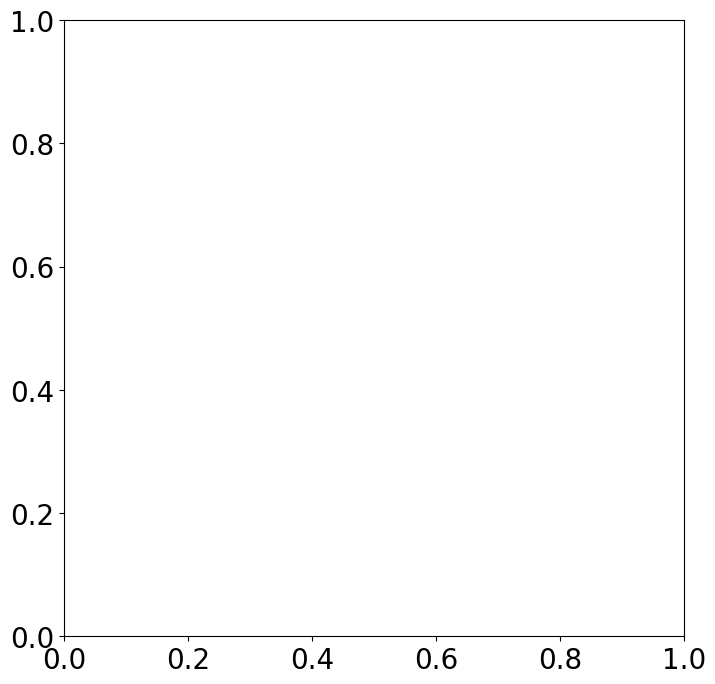

In [23]:
# Define your redshift bins and mass bins
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
mass_bin = [[9.8, 10], [10, 10.2], [10.2, 10.4], [10.4, 10.6], [10.6, 10.8], [10.8, 11], [11, 12]]

colors = ['red', 'orange', 'green', 'dodgerblue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['x'][i][:, 2])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(redshifts)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=rf'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Redshift', fontsize=20)
plt.ylabel(r'$\log$ SFR', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\o'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\o'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1484115729.py:48: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1484115729.py:53: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('SFR ($M_\odot.yr^{-1}$)', fontsize=20)


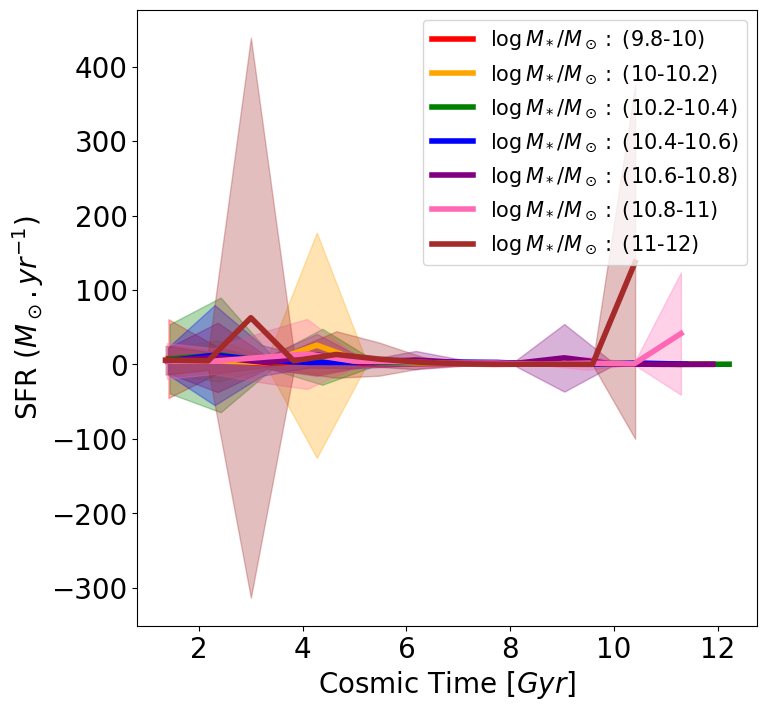

In [24]:
# Define your redshift bins and mass bins
nbins=12
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []
   

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        t = np.array(node_features['t'][i])
        cosmic_times = Planck15.age(redshifts)
        sfr = 10**np.array(node_features['x'][i][:, 2])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
plt.ylabel('SFR ($M_\odot.yr^{-1}$)', fontsize=20)
plt.legend(loc='upper right',fontsize=15)
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


[[0.2781    ]
 [0.99030006]
 [1.2021999 ]
 [1.7281001 ]
 [2.0732    ]
 [2.5823    ]
 [4.0236    ]
 [4.6464    ]]
22417.0


<>:46: SyntaxWarning: invalid escape sequence '\o'
<>:46: SyntaxWarning: invalid escape sequence '\o'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1243316218.py:46: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('SFR ($M_\odot.yr^{-1}$)', fontsize=20)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1243316218.py:46: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('SFR ($M_\odot.yr^{-1}$)', fontsize=20)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\datos2\\22417.0_SFH.fits'

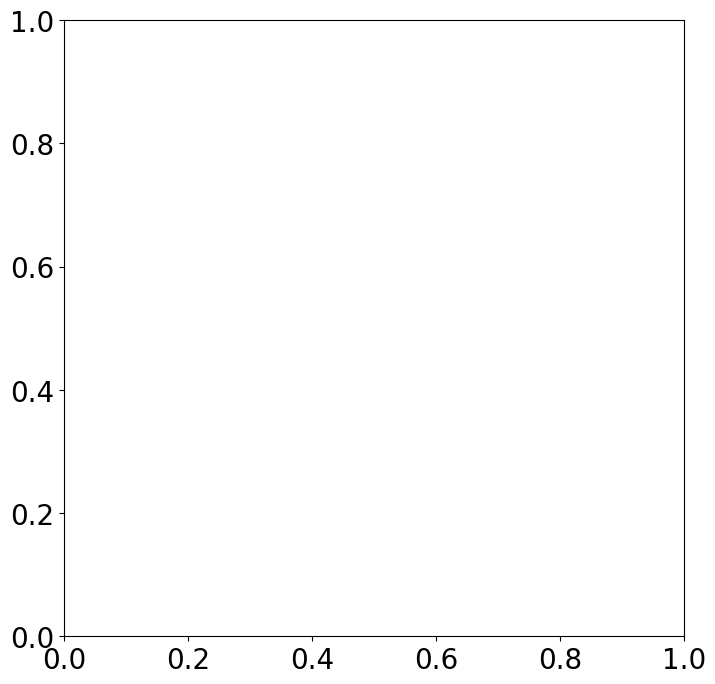

In [25]:
# Define your redshift bins and mass bins
nbins=12
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
#colors = ['blue', 'green', 'purple', 'orange','pink','brown','black']  # Adjust or add more colors for each mass bin
#SFH_path = "/Users/marchuertascompany/Documents/data/COSMOS-Web/automnt/n17data/arango/CIGALE/runs/run_web/COSMOSWEB_1.6_INPUT/out/" 
#### Para mi sfh_path es el path a datos2

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []
   

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(1):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        print(redshifts)
        t = np.array(node_features['t'][i])
        cosmic_times = Planck15.age(redshifts)
        sfr = 10**np.array(node_features['x'][i][:, 2])

        id_val = node_features['id'][i][0, 0]  # Ensure this is how your ID is structured
        print(id_val)
        file_name = f"{id_val}_SFH.fits"
        with fits.open(datos2_data_path+file_name) as hdul:
            data = hdul[1].data  # Assuming the table is in the first extension; adjust if different

            # Convert to a Pandas DataFrame
            sfh_fit = pd.DataFrame({ 'time': data['time'], 'SFR': data['SFR'] })
            print(sfh_fit.time.values)
        plt.plot(cosmic_times, sfr, color='black',label='Florah')  # Use the same color for individual lines, with some alpha
        plt.plot(sfh_fit.time.values*1e-3+cosmic_times[0].value-len(sfh_fit.time.values)*1e-3,sfh_fit.SFR.values,color='red',label='SED fit')
       

        # Finalizing the plot
        plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
        plt.ylabel('SFR ($M_\odot.yr^{-1}$)', fontsize=20)
        plt.legend(loc='upper right',fontsize=15)
        plt.savefig('sfr_growth_CEERS_combined.png')
        plt.show()


<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\162439229.py:45: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\162439229.py:50: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log M_*/M_\odot$', fontsize=20)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\162439229.py:45: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\162439229.py:50: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log M_*/M_\odot$', fontsize=20)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\node_features_morphology\\node_features_9.8_10.pkl'

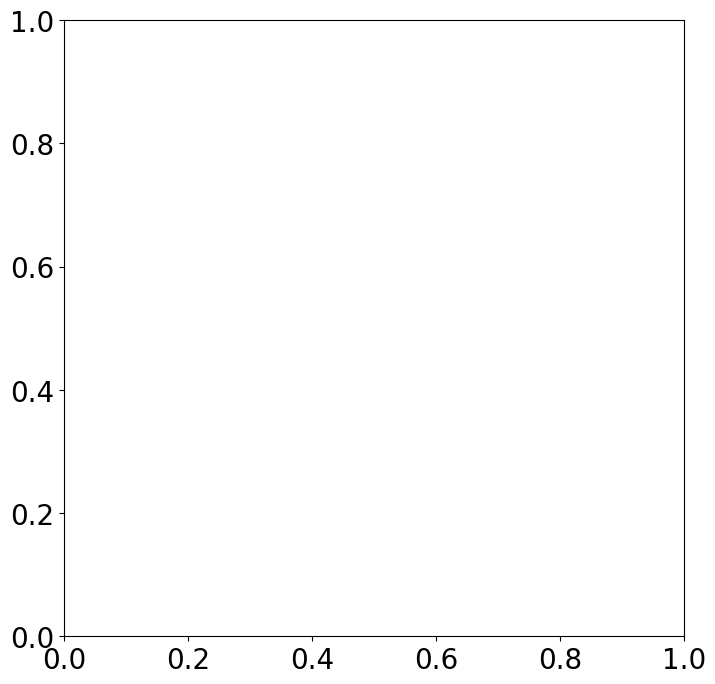

In [26]:
# Define your redshift bins and mass bins
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['x'][i][:, 0])
        
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(redshifts)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Redshift', fontsize=20)
plt.ylabel('$\log M_*/M_\odot$', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


(800,)
(800,)
(800,)
(800,)
(800,)
(712,)
(456,)


<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1423373846.py:46: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)


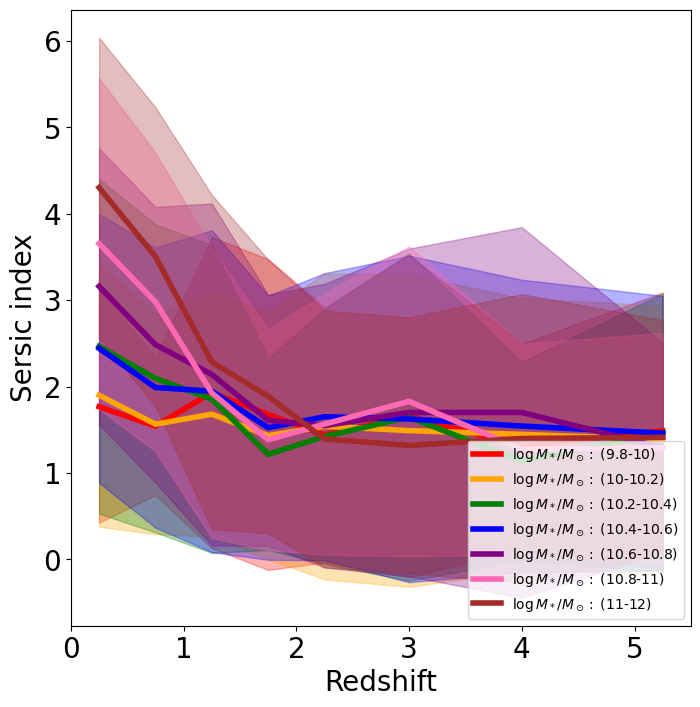

In [27]:
# Define your redshift bins and mass bins
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['sersic'][i])
        
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(redshifts)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.squeeze(np.array(all_sfrs))
    print(all_sfrs_np.shape)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Redshift', fontsize=20)
plt.ylabel('Sersic index', fontsize=20)
plt.legend(loc='lower right')
#plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\2349833089.py:45: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\2349833089.py:50: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log M_*/M_\odot$', fontsize=20)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\2349833089.py:45: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\2349833089.py:50: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log M_*/M_\odot$', fontsize=20)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\node_features_morphology\\node_features_9.8_10.pkl'

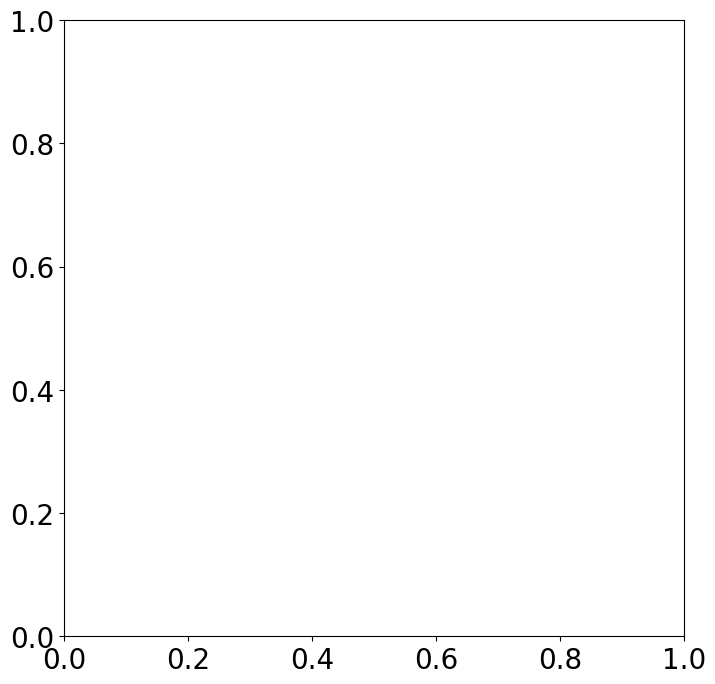

In [28]:
# Define your redshift bins and mass bins
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts)
        sfr = np.array(node_features['x'][i][:, 0])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic time ($Gyrs$)', fontsize=20)
plt.ylabel('$\log M_*/M_\odot$', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\2042743023.py:46: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)


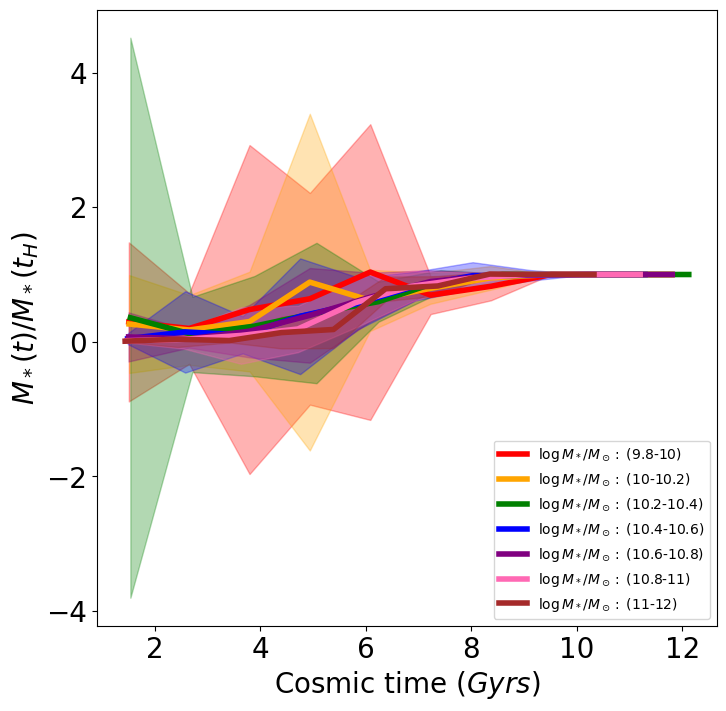

In [29]:
# Define your redshift bins and mass bins
nbins=10
#bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
#colors = ['blue', 'green', 'purple', 'orange']  # Adjust or add more colors for each mass bin
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts)
        sfr = np.array(10**node_features['x'][i][:, 0]/10**node_features['x'][i][0, 0])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic time ($Gyrs$)', fontsize=20)
plt.ylabel('$M_*(t)/M_*(t_H)$', fontsize=20)
plt.legend(loc='lower right')
#plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\2096577628.py:44: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)


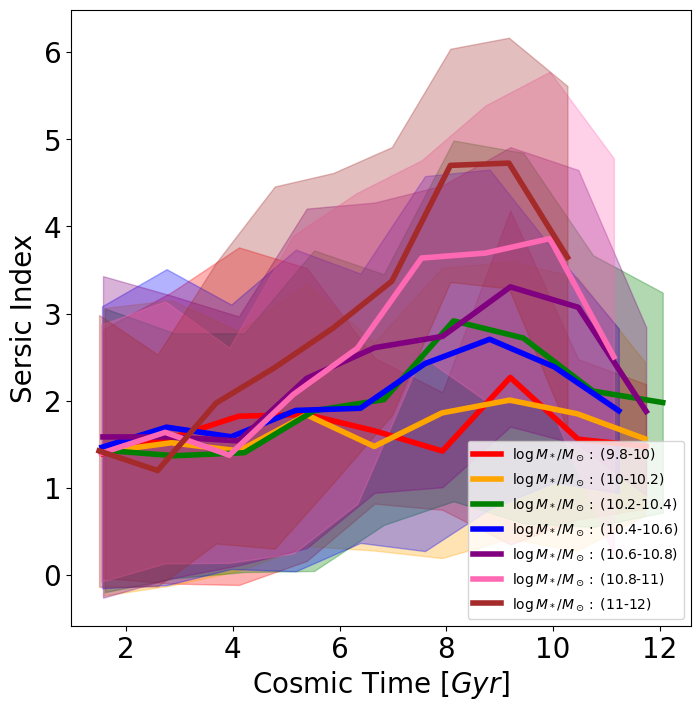

In [30]:
# Define your redshift bins and mass bins
#bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
nbins=9
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts)
        sfr = np.array(node_features['sersic'][i])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.squeeze(np.array(all_sfrs))

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
plt.ylabel('Sersic Index', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
#bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
nbins=12
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts)
        sfr = np.array(node_features['bovert'][i])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.squeeze(np.array(all_sfrs))

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
plt.ylabel('B/T', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
nbins = 12
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path + f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts).value  # Make sure to extract value if it's a Quantity
        morphology = np.array(node_features['morphology'][i])

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(morphology)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.squeeze(np.array(all_sfrs))

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})', lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Replace numerical y-axis values with labels
plt.yticks([0, 1, 2, 3], ['E', 'S', 'I', 'B+D'])

# Finalizing the plot
plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
plt.ylabel('Morphology', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('morphology_evolution.png')
plt.show()


<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\3545489837.py:39: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})', lw=4)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\3545489837.py:39: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})', lw=4)


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'

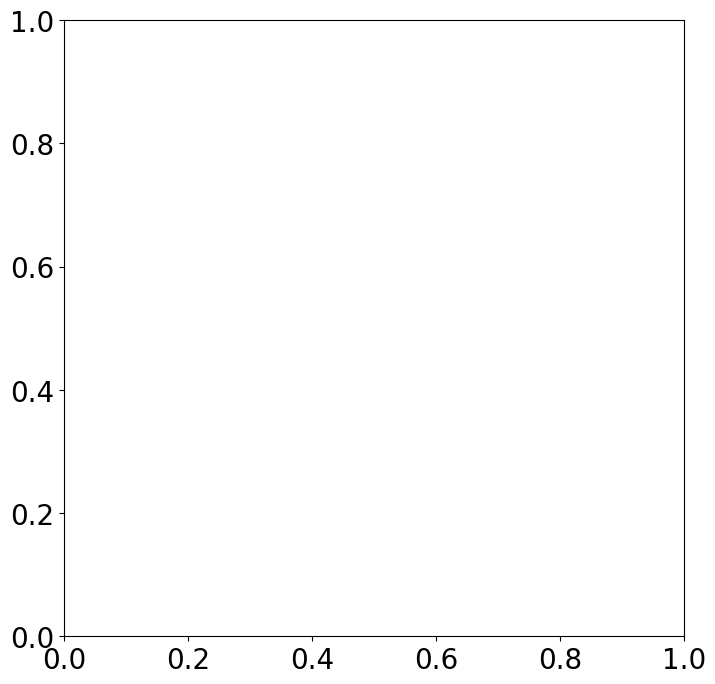

In [31]:
# Setup for plotting and data
nbins = 12
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 
morphology_mapping = {0: 0, 3: 1, 1: 2, 2: 3}


plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

for m_bin, color in zip(mass_bin, colors):
    with open(nfm_data_path + f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_morphologies = []
    all_cosmic_times = []

    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts).value  # convert to Gyr
        morphologies = np.array(node_features['morphology'][i])
        remapped_morphologies = np.vectorize(morphology_mapping.get)(morphologies)  # Remap the morphologies

        all_cosmic_times.extend(cosmic_times)
        all_morphologies.extend(remapped_morphologies)

    all_cosmic_times_np = np.array(all_cosmic_times)
    all_morphologies_np = np.array(all_morphologies)

    valid_data_mask = ~np.isnan(all_cosmic_times_np) & ~np.isnan(all_morphologies_np)
    filtered_cosmic_times = all_cosmic_times_np[valid_data_mask]
    filtered_morphologies = all_morphologies_np[valid_data_mask]

    bin_means, bin_edges, _ = stats.binned_statistic(filtered_cosmic_times, filtered_morphologies, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_cosmic_times, filtered_morphologies, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})', lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Set custom y-axis labels
morphology_labels = ['E', 'B+D', 'S', 'I']
plt.yticks(range(4), morphology_labels)

plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
plt.ylabel('Morphology', fontsize=20)
plt.legend(loc='lower right', fontsize=12)
plt.savefig('morphology_evolution_CEERS_combined.png')
plt.show()


<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\3027365894.py:43: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\3027365894.py:48: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log$ sSFR', fontsize=20)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\3027365894.py:43: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\3027365894.py:48: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log$ sSFR', fontsize=20)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\node_features_morphology\\node_features_9.8_10.pkl'

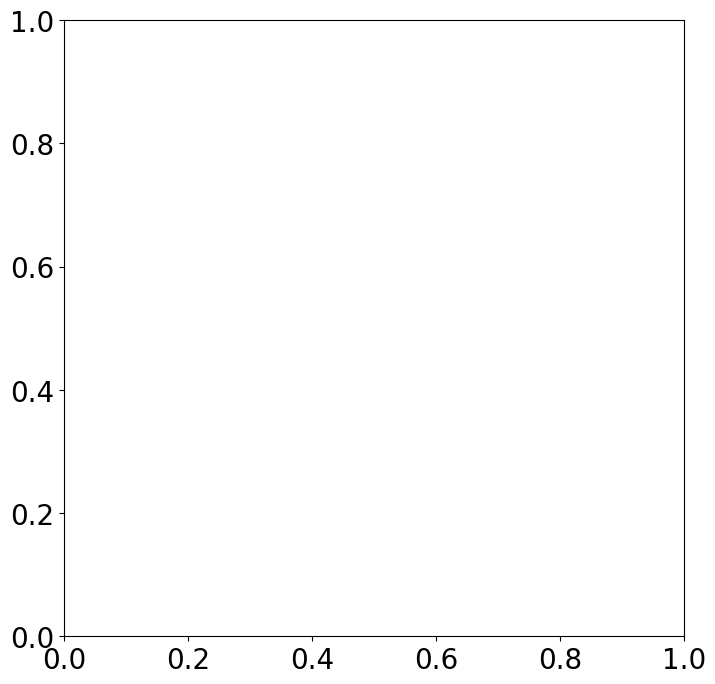

In [32]:
# Define your redshift bins and mass bins
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5,4, 4.5,5,5.5, 6])
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['x'][i][:, 2])
        ssfr = np.log10(10**np.array(node_features['x'][i][:, 2])/10**np.array(node_features['x'][i][:, 0]))
        #plt.plot(redshifts, ssfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(redshifts)
        all_sfrs.extend(ssfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np #[valid_data_mask]
    filtered_sfrs = all_sfrs_np #[valid_data_mask]

    # Binning the data
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Redshift', fontsize=20)
plt.ylabel('$\log$ sSFR', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1253621279.py:46: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1253621279.py:50: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log M_*/M_\odot$', fontsize=20)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1253621279.py:51: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log$ sSFR', fontsize=20)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1253621279.py:46: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=c

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\node_features_morphology\\node_features_9.8_10.pkl'

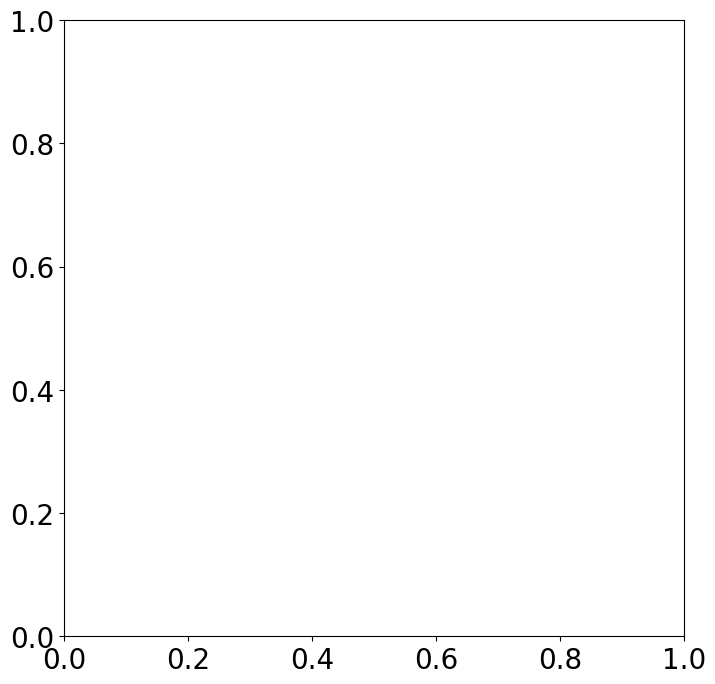

In [33]:
# Define your redshift bins and mass bins
#bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
nbins = 15
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['x'][i][:, 2])
        mstar = np.array(node_features['x'][i][:, 0])
        ssfr = np.log10(10**np.array(node_features['x'][i][:, 2])/10**np.array(node_features['x'][i][:, 0]))
        plt.plot(mstar, ssfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(mstar)
        all_sfrs.extend(ssfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    #valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np
    filtered_sfrs = all_sfrs_np

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('$\log M_*/M_\odot$', fontsize=20)
plt.ylabel('$\log$ sSFR', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1364197814.py:46: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1364197814.py:50: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log M_*/M_\odot$', fontsize=20)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1364197814.py:51: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log R_e$', fontsize=20)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1364197814.py:46: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=co

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\node_features_morphology\\node_features_9.8_10.pkl'

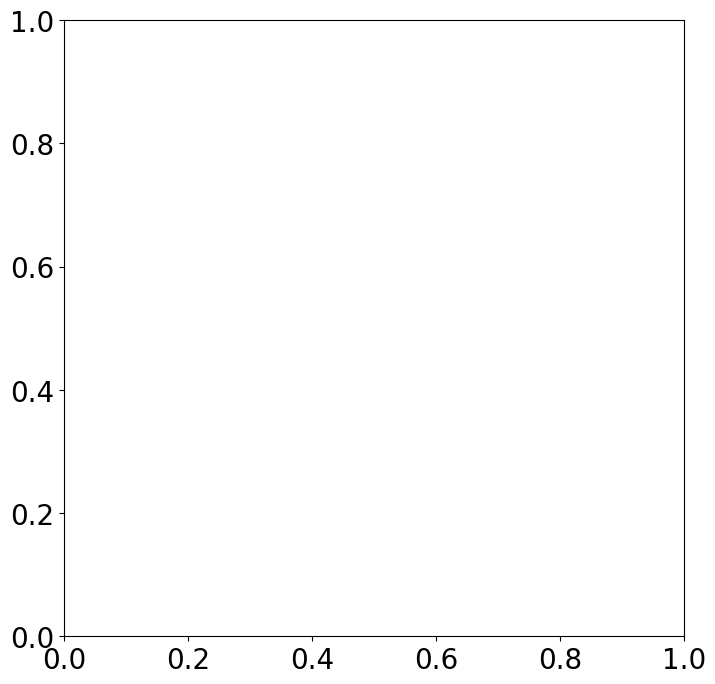

In [34]:
# Define your redshift bins and mass bins
#bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
nbins = 10
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['x'][i][:, 2])
        re = np.array(node_features['x'][i][:, 1])
        mstar = np.array(node_features['x'][i][:, 0])
        ssfr = np.log10(10**np.array(node_features['x'][i][:, 2])/10**np.array(node_features['x'][i][:, 0]))
        #plt.plot(mstar, ssfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(mstar)
        all_sfrs.extend(re)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    #valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np
    filtered_sfrs = all_sfrs_np

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('$\log M_*/M_\odot$', fontsize=20)
plt.ylabel('$\log R_e$', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


### graficas chiquitas de nuevo


(100, 8, 3)


<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\3850251502.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log SFR$',fontsize=20)


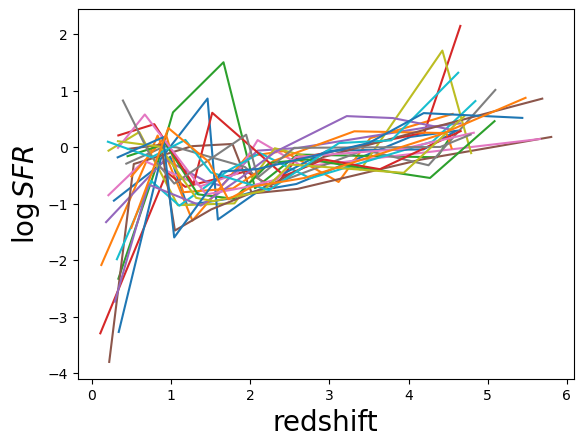

In [35]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(22):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,2]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)

plt.savefig('sfr_growth_CEERS.png')

(100, 8, 3)


<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\3666316471.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log M_*/M_\odot$',fontsize=20)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\3666316471.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log SFR$',fontsize=20)


Text(0, 0.5, '$\\log SFR$')

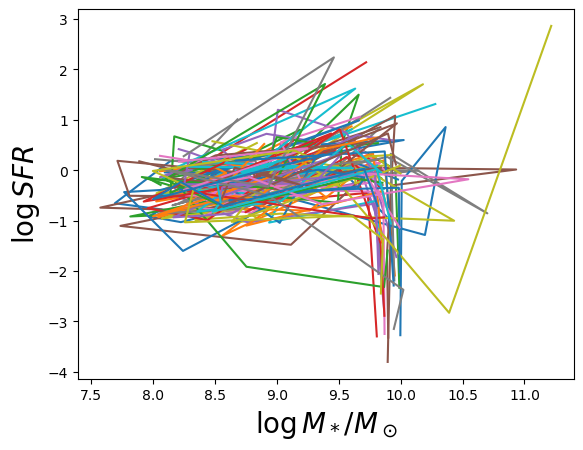

In [36]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(51):
    plt.plot(np.array(node_features['x'][i][:,0]),np.array(node_features['x'][i][:,2]))

plt.xlabel('$\log M_*/M_\odot$',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)

#plt.savefig('sfr_growth_CEERS.png')

(100, 8, 3)


<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1633858401.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log M_*/M_\odot$',fontsize=20)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1633858401.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log SFR$',fontsize=20)


Text(0, 0.5, '$\\log SFR$')

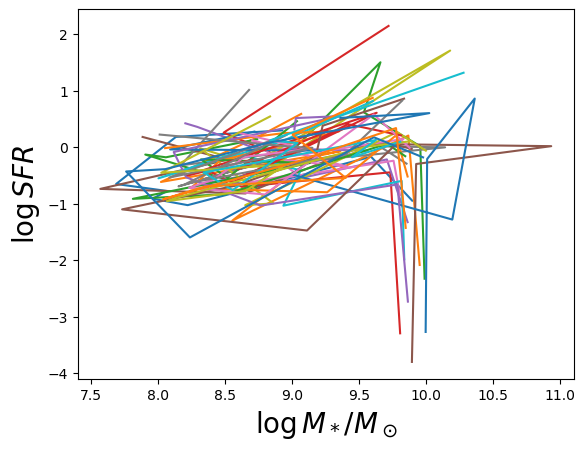

In [37]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(22):
    plt.plot(np.array(node_features['x'][i][:,0]),np.array(node_features['x'][i][:,2]))

plt.xlabel('$\log M_*/M_\odot$',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)

#plt.savefig('sfr_growth_CEERS.png')

(100, 8, 3)


<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1453554242.py:8: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log M_*/M_\odot$',fontsize=20)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\1453554242.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log sSFR$',fontsize=20)


Text(0, 0.5, '$\\log sSFR$')

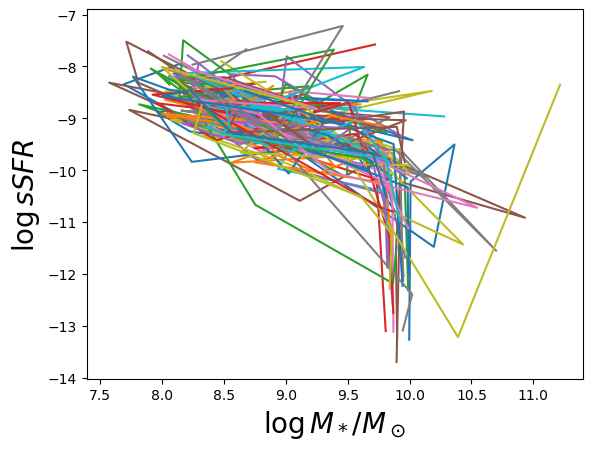

In [38]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(51):
    ssfr = np.log10(10**np.array(node_features['x'][i][:,2])/10**np.array(node_features['x'][i][:,0]))
    plt.plot(np.array(node_features['x'][i][:,0]),ssfr)

plt.xlabel('$\log M_*/M_\odot$',fontsize=20)

plt.ylabel('$\log sSFR$',fontsize=20)

#plt.savefig('sfr_growth_CEERS.png')

(100, 8, 3)


<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\4095760119.py:8: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log M_*/M_\odot$',fontsize=20)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\4095760119.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log sSFR$',fontsize=20)


Text(0, 0.5, '$\\log sSFR$')

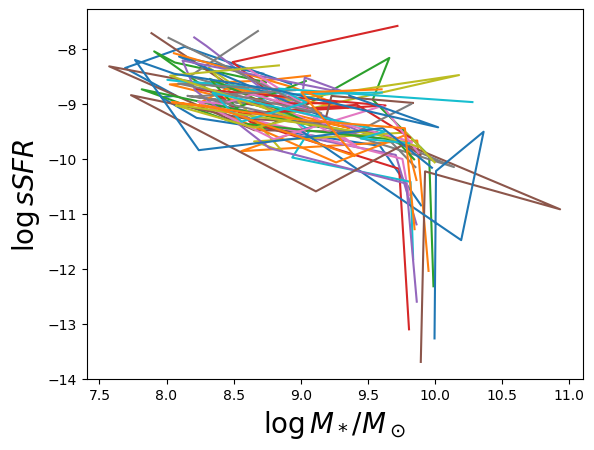

In [39]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(22):
    ssfr = np.log10(10**np.array(node_features['x'][i][:,2])/10**np.array(node_features['x'][i][:,0]))
    plt.plot(np.array(node_features['x'][i][:,0]),ssfr)

plt.xlabel('$\log M_*/M_\odot$',fontsize=20)

plt.ylabel('$\log sSFR$',fontsize=20)

#plt.savefig('sfr_growth_CEERS.png')

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_22412\4134324208.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log M_*$',fontsize=20)


(100, 8, 3)
149.90872
[2.3309445]


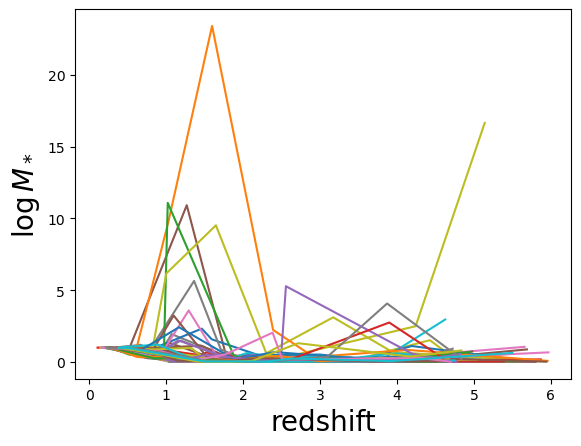

In [40]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(80):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,10**np.array(node_features['x'][i][:,0])/10**np.array(node_features['x'][i][0,0]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log M_*$',fontsize=20)


print(node_features['ra'][11][0][0])
print(node_features['dec'][11][0])

plt.savefig('mass_growth_CEERS.png')

## A partir de aquí mirar:

In [41]:
q = cosmos_cat.query('RA_1>=214.88161 and RA_1<=214.88163 and DEC_1>=52.88396 and DEC_1<=52.88398') ###### RA_1 = ra, DEC_1 = dec
q = cosmos_cat.query('RA_1>='+str(node_features['ra'][i][0][0]-1e-5)+' and RA_1<='+str(node_features['ra'][i][0][0]+1e-5)+' and DEC_1>='+str(node_features['dec'][i][0][0]-1e-5)+' and DEC_1<='+str(node_features['ra'][i][0][0]+1e-5))
#print(q.ID_1)

UndefinedVariableError: name 'RA_1' is not defined

In [ ]:
"""densebasis_dir = '/Users/marchuertascompany/Documents/data/CEERS/DenseBasis/'
db_cat = pd.read_csv(densebasis_dir + "CEERS_v0.51_dense_basis.csv")



#os.listdir(densebasis_dir)
#db_cat = Table.read(densebasis_dir + "CEERS_v0.51_dense_basis.fits", format='ascii.commented_header')

""" ##### Cambiar datos por los de cosmos

In [ ]:
from astropy.cosmology import Planck13,z_at_value
import astropy.units as u

cosmos_sel = cosmos_cat.query('ID == 19566')
sfh=cosmos_sel.sfh_50.values[0]
time = cosmos_sel.timeax.values[0]

# Remove the parentheses and split the string by comma
sfh = sfh.strip('()').split(',')
time = time.strip('()').split(',')

# Convert the strings to float numbers
numbers = [float(num) for num in sfh]
numbers_time = [float(num) for num in time]

# Convert the list of numbers to a NumPy array
sfh_array = np.array(numbers)
time_array = np.array(numbers_time)



cosmo = Planck13

# Convert time to redshift
# Convert time to redshift

print(cosmo.age)

redshift_array = np.array([z_at_value(cosmo.age, (t) * u.Gyr) for t in time_array[1:]])

sfh_array = sfh_array[1:]
plt.plot(redshift_array[redshift_array<5],np.log10(sfh_array[redshift_array<5]))

print(np.array(node_features['x']).shape)
node_features['t'][0]


plt.plot(1/ np.array(node_features['t'][11]) - 1,np.array(node_features['x'][11][:,2]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)  

In [ ]:
from astropy.cosmology import Planck13, z_at_value
import astropy.units as u



# Create a 2x5 grid of subplots (10 panels)
fig, axs = plt.subplots(2, 5, figsize=(15, 6))

first_obj = 68

for i in range(10):
    q = cosmos_cat.query(
        'RA_1>=' + str(node_features['ra'][first_obj+i][0][0] - 1e-5) + ' and RA_1<=' + str(node_features['ra'][first_obj+i][0][0] + 1e-5) +
        ' and DEC_1>=' + str(node_features['dec'][first_obj+i][0][0] - 1e-5) + ' and DEC_1<=' + str(node_features['dec'][first_obj+i][0][0] + 1e-5))


    print(q['ID_1'].values)
    cosmos_sel = cosmos_cat.query('ID == ' + str(q['ID_1'].values[0]))
    sfh = cosmos_sel.sfh_50.values[0]
    sfh_16 = cosmos_sel.sfh_16.values[0]
    sfh_84 = cosmos_sel.sfh_84.values[0]
    time = cosmos_sel.timeax.values[0]

    # Remove the parentheses and split the string by comma
    sfh = sfh.strip('()').split(',')
    sfh_16 = sfh_16.strip('()').split(',')
    sfh_84 = sfh_84.strip('()').split(',')
    time = time.strip('()').split(',')

    # Convert the strings to float numbers
    numbers = [float(num) for num in sfh]
    numbers_16 = [float(num) for num in sfh_16]
    numbers_84 = [float(num) for num in sfh_84]
    numbers_time = [float(num) for num in time]

    # Convert the list of numbers to a NumPy array
    sfh_array = np.array(numbers)
    sfh_array_16 = np.array(numbers_16)
    sfh_array_84 = np.array(numbers_84)
    time_array = np.array(numbers_time)

    cosmo = Planck13

    # Convert time to redshift
    redshift_array = np.array([z_at_value(cosmo.age, t * u.Gyr) for t in time_array[1:]])

    sfh_array = sfh_array[1:]
    #print(sfh_array[1:])
    sfh_array_16 = sfh_array_16[1:]
    sfh_array_84 = sfh_array_84[1:]

    # Determine the subplot location in the 2x5 grid
    row = i // 5
    col = i % 5

    # Plot the data on the current subplot
    #axs[row, col].plot(redshift_array[redshift_array < 5], np.log10(sfh_array[redshift_array < 5]))
    axs[row, col].fill_between(redshift_array[redshift_array < 6], np.log10(sfh_array_16[redshift_array < 6]),np.log10(sfh_array_84[redshift_array < 6]),color='red',alpha=0.5,label='DenseBasis')
    axs[row, col].set_title(f'ID '+str(q['ID_1'].values[0]))
    axs[row, col].plot(1/ np.array(node_features['t'][first_obj+i]) - 1,np.array(node_features['x'][first_obj+i][:,2]),lw=4,color='black',label='Florah')
    axs[row, col].legend(loc='lower right')
    axs[row, col].set_ylim((-4,2.5))
# Set common labels for the entire figure
fig.text(0.5, 0.001, 'Redshift', ha='center', fontsize=20)
fig.text(0.001, 0.5, '$\log SFR$', va='center', rotation='vertical', fontsize=20)

# Adjust subplot layout and show the figure
plt.tight_layout()
plt.savefig('SFH_comparisons.png')
plt.show()


In [ ]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.coordinates import match_coordinates_sky

c = SkyCoord(ra=ra1*u.degree, dec=dec1*u.degree)

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(10):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,1]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log R_e$',fontsize=20)    

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(1):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,2]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)      

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(20):
    plt.plot(np.array(node_features['x'][i][:,0]),np.array(node_features['x'][i][:,2]))

plt.xlabel('$\log M_*/M_\odot$',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)    

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(20):
    plt.plot(np.array(node_features['x'][i][:,0]),np.array(node_features['x'][i][:,1]))


plt.xlabel('$\log M_*/M_\odot$',fontsize=20)

plt.ylabel('$\log Re$',fontsize=20)   